## 1. Cargar los datos (trainmod).

In [26]:
import pandas as pd

Cargamos el contenido del csv en el DataFrame `datos`

In [27]:
datos = pd.read_csv("/content/sample_data/trainmod.csv")

In [28]:
datos.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,Crisis,Reforma
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,0,2,2008,WD,Normal,208500,SI,5
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,0,5,2007,WD,Normal,181500,NO,31
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,0,9,2008,WD,Normal,223500,SI,6
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,0,2,2006,WD,Abnorml,140000,NO,36
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,0,12,2008,WD,Normal,250000,SI,8


A la hora de buscar Outliers debo fijarne en las variables numéricas.

Pero es posible que algunas variables cuyos datos se guarden en forma de números estén enmascarando valores categóricos. Por ejemplo las tallas de una base de datos de pantalones.

También es posible que algunas variables numéricas estén acotadas por su naturaleza, por ejemplo las "notas" del 0 al 10 que se ven en algunas de las columnas de la tabla. O los años de construcción, remodelación...

La columna PoolArea, por ejemplo, sólo tiene valores distintos de 0 en 7 ocasiones. Sólo hay 7 viviendas con piscina por lo que, al ser un suceso "anómalo" en nuestros datos, quizá sea mejos considerarlo un booleano (vivienda con piscina - sin piscina)

In [29]:
sum(datos["PoolArea"]!=0)

7

In [30]:
datos["Piscina"] = datos["PoolArea"] != 0
del datos["PoolArea"]
datos.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,Crisis,Reforma,Piscina
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,0,2,2008,WD,Normal,208500,SI,5,False
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,0,5,2007,WD,Normal,181500,NO,31,False
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,0,9,2008,WD,Normal,223500,SI,6,False
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,0,2,2006,WD,Abnorml,140000,NO,36,False
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,0,12,2008,WD,Normal,250000,SI,8,False


## 2. Seleccionar los datos numéricos.

Vamos a ver lor tipos de datos que tengo:

<Axes: >

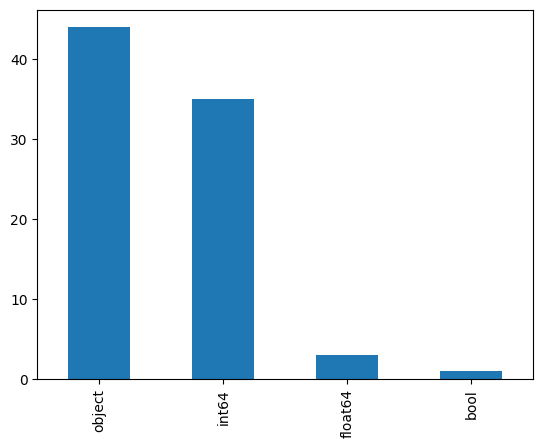

In [31]:
datos.dtypes.value_counts().plot(kind="bar")

La función describe() (por defecto) nos devuelve el resumen de los datos numéricos.

Obtenemos una mejor visualización transponiendo el resultado.

In [32]:
datos.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


Puedo seleccionar las columnas numéricas a partir de las columnas que nos devuelve el dataframe `describe()`.

In [33]:
columnas_numericas = datos.describe().columns
columnas_numericas

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'X1stFlrSF', 'X2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', 'X3SsnPorch', 'ScreenPorch', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice', 'Reforma'],
      dtype='object')

In [34]:
datos_numericos = datos[columnas_numericas]

In [35]:
datos_numericos.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,X3SsnPorch,ScreenPorch,MiscVal,MoSold,YrSold,SalePrice,Reforma
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,61,0,0,0,0,2,2008,208500,5
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,298,0,0,0,0,0,5,2007,181500,31
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,42,0,0,0,0,9,2008,223500,6
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,35,272,0,0,0,2,2006,140000,36
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,192,84,0,0,0,0,12,2008,250000,8


Otra manera de hacerlo

In [36]:
import numpy as np
datos_numericos2 = datos.select_dtypes(np.number)
datos_numericos2

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,X3SsnPorch,ScreenPorch,MiscVal,MoSold,YrSold,SalePrice,Reforma
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,61,0,0,0,0,2,2008,208500,5
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,298,0,0,0,0,0,5,2007,181500,31
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,42,0,0,0,0,9,2008,223500,6
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,35,272,0,0,0,2,2006,140000,36
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,192,84,0,0,0,0,12,2008,250000,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,1999,2000,0.0,0,...,0,40,0,0,0,0,8,2007,175000,7
1456,1457,20,85.0,13175,6,6,1978,1988,119.0,790,...,349,0,0,0,0,0,2,2010,210000,22
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275,...,0,60,0,0,0,2500,5,2010,266500,4
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49,...,366,0,112,0,0,0,4,2010,142125,14


El resultado es el mismo

In [37]:
datos_numericos.columns == datos_numericos2.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])

## 3. Realizar un boxplot de dichos datos.

Puedo obtener boxplots columna por columna

<Axes: >

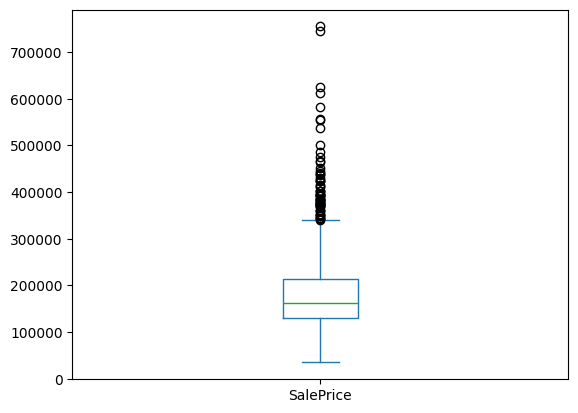

In [38]:
datos_numericos["SalePrice"].plot(kind = "box")

Si intento ver todas las columnas a la vez voy a tener que lidiar con el problema de que las escalas de cada columna son diferentes.

Los precios se cuentan por centenares de miles, las superficies por miles y el número de baños por unidades.

<Axes: >

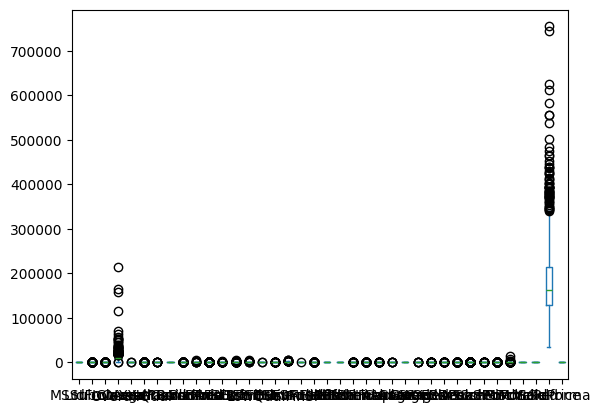

In [39]:
datos_numericos.plot(kind = "box")

In [40]:
datos_numericos.apply(max)

,0
Id,1460.0
MSSubClass,190.0
LotFrontage,313.0
LotArea,215245.0
OverallQual,10.0
OverallCond,9.0
YearBuilt,2010.0
YearRemodAdd,2010.0
MasVnrArea,1600.0
BsmtFinSF1,5644.0


Puedo utilizar los máximos (y los mínimos) para graficarjuntas las variables que se mueven en los mismos rangos.

Index(['BsmtFinSF1', 'TotalBsmtSF', 'GrLivArea'], dtype='object')

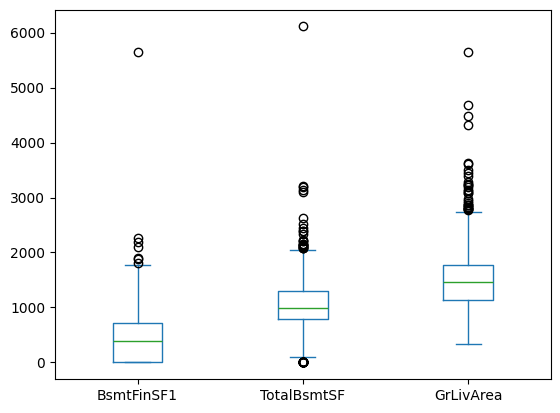

In [41]:
datos_numericos.iloc[:,[9,12,16]].plot(kind = "box")
datos_numericos.iloc[:,[9,12,16]].columns

## 4. Determinar numéricos y categóricos
Qué datos son realmente numéricos y pueden tener outliers y cuales son categóricos, aunque con forma numérica y repetir el boxplot.


In [42]:
datos_numericos.apply(pd.Series.nunique)

,0
Id,1460
MSSubClass,15
LotFrontage,110
LotArea,1073
OverallQual,10
OverallCond,9
YearBuilt,112
YearRemodAdd,61
MasVnrArea,327
BsmtFinSF1,637


Las variables categóricas se detectan viendo que el número de valores únicos que pueden tomar es limitado.

Consideramos como categóricas las columnas con menos de 24 valores únicos

In [43]:
columnas_cat = datos_numericos.apply(pd.Series.nunique) < 24
columnas_cat

,0
Id,False
MSSubClass,True
LotFrontage,False
LotArea,False
OverallQual,True
OverallCond,True
YearBuilt,False
YearRemodAdd,False
MasVnrArea,False
BsmtFinSF1,False


In [44]:
columnas_cat = columnas_cat.index[columnas_cat]
columnas_cat

Index(['MSSubClass', 'OverallQual', 'OverallCond', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'X3SsnPorch', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='object')

In [46]:
#Consideramos como categóricas las columnas con menos de 24 valores únicos
datos_no_categoricos = datos_numericos[datos_numericos.columns[datos_numericos.nunique() >= 24]]
datos_no_categoricos

,Id,LotFrontage,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,...,LowQualFinSF,GrLivArea,GarageYrBlt,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SalePrice,Reforma
0,1,65.0,8450,2003,2003,196.0,706,0,150,856,...,0,1710,2003.0,548,0,61,0,0,208500,5
1,2,80.0,9600,1976,1976,0.0,978,0,284,1262,...,0,1262,1976.0,460,298,0,0,0,181500,31
2,3,68.0,11250,2001,2002,162.0,486,0,434,920,...,0,1786,2001.0,608,0,42,0,0,223500,6
3,4,60.0,9550,1915,1970,0.0,216,0,540,756,...,0,1717,1998.0,642,0,35,272,0,140000,36
4,5,84.0,14260,2000,2000,350.0,655,0,490,1145,...,0,2198,2000.0,836,192,84,0,0,250000,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,62.0,7917,1999,2000,0.0,0,0,953,953,...,0,1647,1999.0,460,0,40,0,0,175000,7
1456,1457,85.0,13175,1978,1988,119.0,790,163,589,1542,...,0,2073,1978.0,500,349,0,0,0,210000,22
1457,1458,66.0,9042,1941,2006,0.0,275,0,877,1152,...,0,2340,1941.0,252,0,60,0,0,266500,4
1458,1459,68.0,9717,1950,1996,0.0,49,1029,0,1078,...,0,1078,1950.0,240,366,0,112,0,142125,14


In [47]:
datos_cat = datos_numericos[columnas_cat]
datos_num_no_cat = datos_numericos.loc[:,~datos_numericos.columns.isin(columnas_cat)]

In [48]:
datos_num_no_cat

,Id,LotFrontage,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,...,LowQualFinSF,GrLivArea,GarageYrBlt,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SalePrice,Reforma
0,1,65.0,8450,2003,2003,196.0,706,0,150,856,...,0,1710,2003.0,548,0,61,0,0,208500,5
1,2,80.0,9600,1976,1976,0.0,978,0,284,1262,...,0,1262,1976.0,460,298,0,0,0,181500,31
2,3,68.0,11250,2001,2002,162.0,486,0,434,920,...,0,1786,2001.0,608,0,42,0,0,223500,6
3,4,60.0,9550,1915,1970,0.0,216,0,540,756,...,0,1717,1998.0,642,0,35,272,0,140000,36
4,5,84.0,14260,2000,2000,350.0,655,0,490,1145,...,0,2198,2000.0,836,192,84,0,0,250000,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,62.0,7917,1999,2000,0.0,0,0,953,953,...,0,1647,1999.0,460,0,40,0,0,175000,7
1456,1457,85.0,13175,1978,1988,119.0,790,163,589,1542,...,0,2073,1978.0,500,349,0,0,0,210000,22
1457,1458,66.0,9042,1941,2006,0.0,275,0,877,1152,...,0,2340,1941.0,252,0,60,0,0,266500,4
1458,1459,68.0,9717,1950,1996,0.0,49,1029,0,1078,...,0,1078,1950.0,240,366,0,112,0,142125,14


Aún así, se puede ver que hay columnas referentes a años como YearBuilt	o YearRemodAdd que todavía no se pueden considerar como generadores de Outliers

<Axes: >

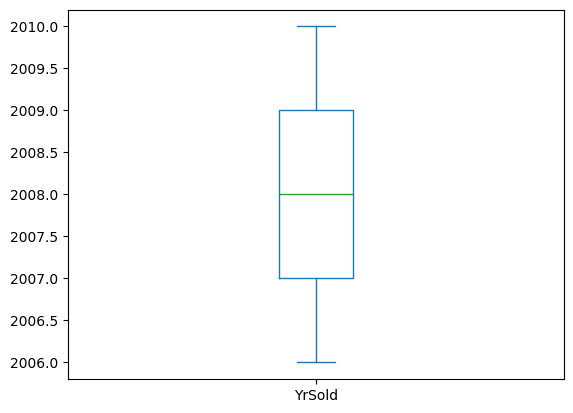

In [49]:
datos_cat['YrSold'].plot(kind = "box")

## 5. Excluir variables distorsionantes y repetir el boxplot.
  

In [50]:
datos_num_no_cat.columns

Index(['Id', 'LotFrontage', 'LotArea', 'YearBuilt', 'YearRemodAdd',
       'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
       'X1stFlrSF', 'X2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'GarageYrBlt',
       'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
       'ScreenPorch', 'SalePrice', 'Reforma'],
      dtype='object')

In [51]:
from matplotlib import pyplot as plt

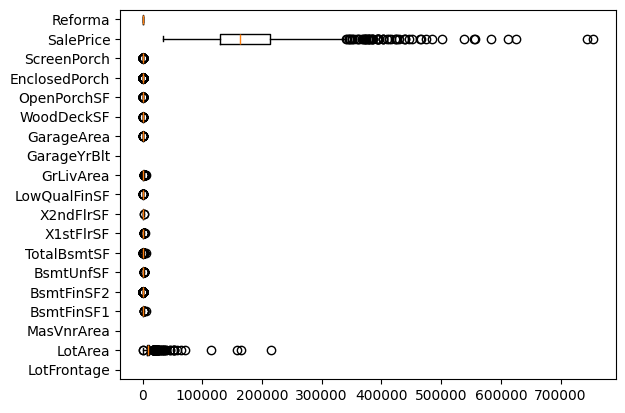

In [52]:
datos_a_graficar = datos_num_no_cat.drop(['Id','YearBuilt', 'YearRemodAdd'], axis = 1)
plt.boxplot(datos_a_graficar, vert=False, tick_labels=datos_a_graficar.columns);

En drop voy añadiendo las columnas distorsionantes

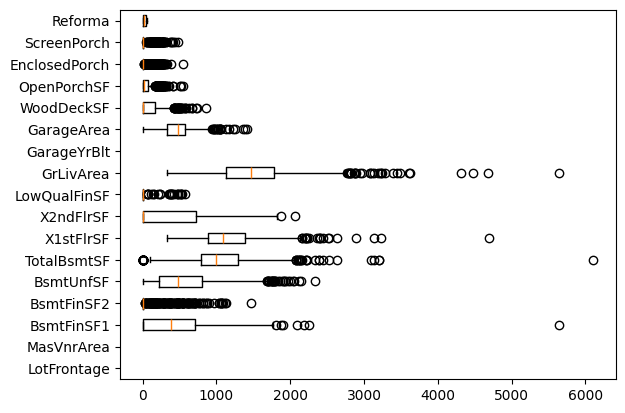

In [53]:
datos_a_graficar = datos_num_no_cat.drop(['Id','YearBuilt', 'YearRemodAdd', 'SalePrice', 'LotArea'], axis = 1)
plt.boxplot(datos_a_graficar, vert=False, tick_labels=datos_a_graficar.columns);

/tmp/ipython-input-54-3680078558.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos_num_no_cat.drop(distorsionantes, axis = 1),


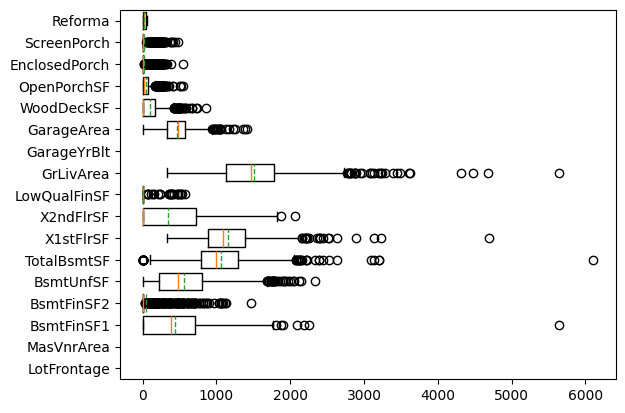

In [54]:
distorsionantes = ['Id','YearBuilt', 'YearRemodAdd', 'SalePrice', 'LotArea']
etiquetas = datos_num_no_cat.drop(distorsionantes, axis = 1).columns
plt.boxplot(datos_num_no_cat.drop(distorsionantes, axis = 1),
            notch=None,
            sym=None,
            vert=False, # False para horizontal
            whis=None, # Posición de los bigotes (por defecto 1.5)
            positions=None,
            widths=0.8, # Anchura como porción del total de la del gráfico
            patch_artist=None,
            bootstrap=None,
            usermedians=None,
            conf_intervals=None,
            meanline=True,
            showmeans=True,
            showcaps=None,
            showbox=None,
            showfliers=None,
            boxprops=None,
            labels=etiquetas, # Etiqueta del valor
            flierprops=None,
            medianprops=None,
            meanprops=None,
            capprops=None,
            whiskerprops=None,
            manage_ticks=True,
            autorange=False,
            zorder=None,
            capwidths=None,
);

## 6. Realizar el boxplot por grupos

y en caso de ser necesario eliminar o modificar alguna variable hasta extraer conclusiones fiables.

<Axes: >

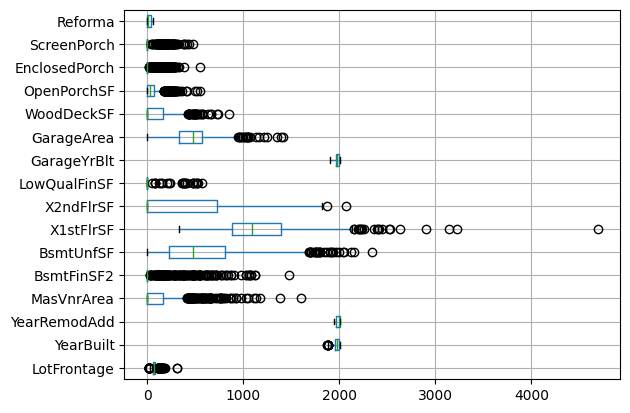

In [55]:
datos_num_no_cat.drop(["SalePrice", "LotArea", 'BsmtFinSF1', 'TotalBsmtSF', 'GrLivArea', "Id"], axis = 1).boxplot(vert=False)

In [56]:
datos_num_no_cat.drop(["SalePrice", "LotArea", 'BsmtFinSF1', 'TotalBsmtSF', 'GrLivArea'], axis = 1).iloc[:, 6]

,BsmtUnfSF
0,150
1,284
2,434
3,540
4,490
...,...
1455,953
1456,589
1457,877
1458,0


   ## 7. Determinar en qué observaciones se encuentran los outliers realizando para ello las modificaciones que sean necesarias.

Vamos a realizar la detección de outliers para la columna SalePrice, pero podría hacerse para otras columnas

In [57]:
# Calcular el rango intercuartílico (IQR)
Q1 = datos_num_no_cat["SalePrice"].quantile(0.25)
Q3 = datos_num_no_cat["SalePrice"].quantile(0.75)
IQR = Q3 - Q1
print(IQR, Q1, Q3)

84025.0 129975.0 214000.0


In [58]:
# Definir los límites para identificar outliers
limite_inferior = Q1 - 1 * IQR
limite_superior = Q3 + 2 * IQR

# Filtrar los outliers
outliers = datos_num_no_cat[(datos_num_no_cat["SalePrice"] < limite_inferior) | (datos_num_no_cat["SalePrice"] > limite_superior)]
no_outliers = datos_num_no_cat[~((datos_num_no_cat["SalePrice"] < limite_inferior) | (datos_num_no_cat["SalePrice"] > limite_superior))]

# Imprimir los resultados
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)
print("Número de outliers:", len(outliers))
print("Outliers:")
outliers

Límite inferior: 45950.0
Límite superior: 382050.0
Número de outliers: 43
Outliers:


,Id,LotFrontage,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,...,LowQualFinSF,GrLivArea,GarageYrBlt,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SalePrice,Reforma
30,31,50.0,8500,1920,1950,0.0,0,0,649,649,...,0,1317,1920.0,250,0,54,172,0,40000,58
53,54,68.0,50271,1981,1987,0.0,1810,0,32,1842,...,0,1842,1981.0,894,857,72,0,0,385000,19
58,59,66.0,13682,2006,2006,1031.0,0,0,1410,1410,...,0,2945,2006.0,641,192,0,37,0,438780,0
112,113,77.0,9965,2007,2007,220.0,984,0,280,1264,...,0,2696,2007.0,792,120,184,0,168,383970,0
161,162,110.0,13688,2003,2004,664.0,1016,0,556,1572,...,0,2668,2003.0,726,400,0,0,0,412500,4
178,179,63.0,17423,2008,2009,748.0,1904,0,312,2216,...,0,2234,2009.0,1166,0,60,0,0,501837,0
185,186,90.0,22950,1892,1993,0.0,0,0,1107,1107,...,572,3608,1993.0,840,0,260,0,410,475000,13
224,225,103.0,13472,2003,2003,922.0,56,0,2336,2392,...,0,2392,2003.0,968,248,105,0,0,386250,6
231,232,174.0,15138,1995,1996,506.0,689,0,773,1462,...,0,2794,1995.0,810,0,146,202,0,403000,13
278,279,107.0,14450,2006,2007,315.0,0,0,2121,2121,...,0,2121,2007.0,732,124,98,0,142,415298,0


## 8. Visualizar las observaciones que tienen outliers de otra forma distinta.


<Axes: >

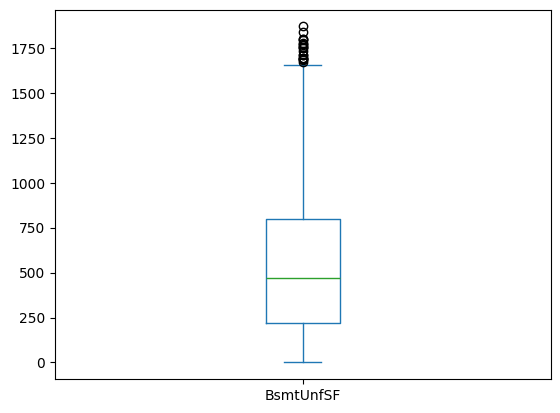

In [ ]:
from scipy import stats
datos2 = datos[(np.abs(stats.zscore(datos["BsmtUnfSF"])) < 3)]
datos2["BsmtUnfSF"].plot(kind = "box")

## 9. Transformar los outliers en NAs
para poder procesarlos posteriormente.

---

Aplicarlo a los datos numéricos (correctos) excepto la “Id” y “SalePrice”.

Las filas con valores de "BsmtUnfSF" más alejados de la media en tres veces la desviación típica aparecerán como true en esta serie

In [ ]:
np.abs(stats.zscore(datos["BsmtUnfSF"])) > 3

array([False, False, False, ..., False, False, False])

Así vemos el número de outliers que han salido

In [ ]:
(np.abs(stats.zscore(datos["BsmtUnfSF"])) > 3).sum()

np.int64(11)

Comprobamos que no hay nulos en esa columna

In [ ]:
datos.isnull()["BsmtUnfSF"].sum()

np.int64(0)

Vamos a convertir los outliers en nulos

Los vemos...

In [ ]:
filtro = np.abs(stats.zscore(datos["BsmtUnfSF"])) > 3
datos.loc[filtro, "BsmtUnfSF"]

,BsmtUnfSF
137,1907
224,2336
278,2121
477,2153
496,1969
581,2042
678,2046
774,1935
798,1926
932,1905


In [ ]:
datos.loc[filtro, "BsmtUnfSF"] = np.nan

Ya no los vemos

In [ ]:
datos.loc[filtro, "BsmtUnfSF"]

,BsmtUnfSF
137,NaN
224,NaN
278,NaN
477,NaN
496,NaN
581,NaN
678,NaN
774,NaN
798,NaN
932,NaN


Ahora son nulos

In [ ]:
datos.isnull()["BsmtUnfSF"].sum()

np.int64(11)

In [ ]:
id = datos["Id"]
saleprice = datos["SalePrice"]

In [ ]:
datos_num.isnull().sum()

,0
Id,0
MSSubClass,0
LotFrontage,259
LotArea,0
OverallQual,0
OverallCond,0
YearBuilt,0
YearRemodAdd,0
MasVnrArea,8
BsmtFinSF1,0


In [ ]:
def replace(columna):
    mean, std = columna.mean(), columna.std()
    outliers = (columna - mean).abs() > 2*std
    print(f"Eliminaremos {outliers.sum()} valores en la columna")
    columna[outliers] = np.nan
    return columna

datos_num = datos_num.apply(replace)

Eliminaremos 0 valores en la columna
Eliminaremos 103 valores en la columna
Eliminaremos 60 valores en la columna
Eliminaremos 22 valores en la columna
Eliminaremos 86 valores en la columna
Eliminaremos 125 valores en la columna
Eliminaremos 47 valores en la columna
Eliminaremos 0 valores en la columna
Eliminaremos 68 valores en la columna
Eliminaremos 48 valores en la columna
Eliminaremos 82 valores en la columna
Eliminaremos 75 valores en la columna
Eliminaremos 76 valores en la columna
Eliminaremos 55 valores en la columna
Eliminaremos 48 valores en la columna
Eliminaremos 22 valores en la columna
Eliminaremos 59 valores en la columna
Eliminaremos 16 valores en la columna
Eliminaremos 82 valores en la columna
Eliminaremos 42 valores en la columna
Eliminaremos 12 valores en la columna
Eliminaremos 85 valores en la columna
Eliminaremos 68 valores en la columna
Eliminaremos 95 valores en la columna
Eliminaremos 120 valores en la columna
Eliminaremos 68 valores en la columna
Eliminaremo

In [ ]:
datos_num.isnull().sum()

,0
Id,0
MSSubClass,103
LotFrontage,319
LotArea,22
OverallQual,86
OverallCond,125
YearBuilt,47
YearRemodAdd,0
MasVnrArea,76
BsmtFinSF1,48


## 10. Juntar el resto de los datos para volver a crear la tabla con todas las variables.

In [ ]:
datos_num["SalePrice"] = saleprice
datos_num["Id"] = id

## 11. Guardar, con un nombre diferente, el data frame que se seleccione.

In [ ]:
datos_num.to_csv("/content/sample_data/datos_podados.csv")